In [1]:
%pip install -U "kagglehub[pandas-datasets]"


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: /Applications/Xcode.app/Contents/Developer/usr/bin/python3 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = 'training.1600000.processed.noemoticon.csv'

df_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    'kazanova/sentiment140',
    file_path,
    pandas_kwargs={
        'encoding': 'latin-1',
        'header': None,
        'on_bad_lines': 'skip',
    },
)

df_raw.head()

/Users/pete/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/pete/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,0,1,2,3,4,5
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [3]:
df = df_raw.copy()
df.columns = ['target', 'id', 'date', 'flag', 'user', 'text']
df['target'] = df['target'].replace(4,1)
df = df[['text', 'target']]
df.head()

,text,target
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",0
1,is upset that he can't update his Facebook by ...,0
2,@Kenichan I dived many times for the ball. Man...,0
3,my whole body feels itchy and like its on fire,0
4,"@nationwideclass no, it's not behaving at all....",0


In [4]:
import re

def clean_tweet(text):
    text = text.lower()  # lowercase

    text = re.sub(r'http\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+', '', text)     # remove mentions
    text = re.sub(r'#\w+', '', text)     # remove hashtags

    text = re.sub(r'[^a-z\s]', '', text) # remove punctuation/numbers
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces

    return text

In [5]:
df['clean_text'] = df['text'].apply(clean_tweet)
df[['text', 'clean_text']].head()

,text,clean_text
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...


In [6]:
from sklearn.model_selection import train_test_split

X = df['clean_text']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [7]:
print(X_train.shape)
print(X_test.shape)

(1280000,)
(320000,)


In [8]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

In [9]:
X_train_tfidf.shape

(1280000, 5000)

In [10]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)

model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000, random_state=42, solver='liblinear')

In [11]:
y_pred = model.predict(X_test_tfidf)

In [12]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.79601875

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.78      0.79    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



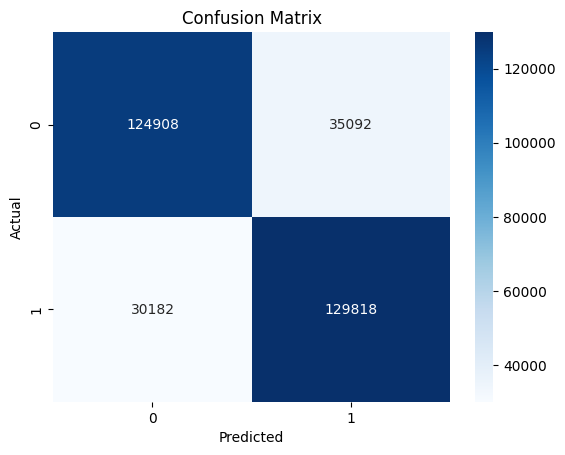

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [14]:
model = LogisticRegression(max_iter=1000, C=2, solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
print("New Accuracy:", accuracy_score(y_test, y_pred))

New Accuracy: 0.796153125


In [15]:
model = LogisticRegression(max_iter=1000, C=0.5, solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

from sklearn.metrics import accuracy_score
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.796109375


In [16]:
import re

def clean_tweet_advanced(text):
    text = text.lower()

    # replace urls and mentions with tokens
    text = re.sub(r'http\S+|www\S+', ' URL ', text)
    text = re.sub(r'@\w+', ' USER ', text)

    # convert hashtags to words only
    text = re.sub(r'#(\w+)', r' \1 ', text)

    # simple emoticon handling
    text = re.sub(r':\)', ' smile ', text)
    text = re.sub(r':-\)', ' smile ', text)
    text = re.sub(r':d', ' laugh ', text)
    text = re.sub(r':\(', ' sad ', text)
    text = re.sub(r':-\(', ' sad ', text)
    text = re.sub(r'<3', ' love ', text)

    # reduce repeated characters: soooo -> soo
    text = re.sub(r'(.)\1{2,}', r'\1\1', text)

    # keep only letters and spaces
    text = re.sub(r'[^a-z\s]', ' ', text)

    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text

In [17]:
df['clean_text_advanced'] = df['text'].apply(clean_tweet_advanced)
df[['text', 'clean_text', 'clean_text_advanced']].head(10)

,text,clean_text,clean_text_advanced
0,"@switchfoot http://twitpic.com/2y1zl - Awww, t...",awww thats a bummer you shoulda got david carr...,a that s a bummer you shoulda got david carr o...
1,is upset that he can't update his Facebook by ...,is upset that he cant update his facebook by t...,is upset that he can t update his facebook by ...
2,@Kenichan I dived many times for the ball. Man...,i dived many times for the ball managed to sav...,i dived many times for the ball managed to sav...
3,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire,my whole body feels itchy and like its on fire
4,"@nationwideclass no, it's not behaving at all....",no its not behaving at all im mad why am i her...,no it s not behaving at all i m mad why am i h...
5,@Kwesidei not the whole crew,not the whole crew,not the whole crew
6,Need a hug,need a hug,need a hug
7,@LOLTrish hey long time no see! Yes.. Rains a...,hey long time no see yes rains a bit only a bi...,hey long time no see yes rains a bit only a bi...
8,@Tatiana_K nope they didn't have it,nope they didnt have it,nope they didn t have it
9,@twittera que me muera ?,que me muera,que me muera


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

X = df['clean_text_advanced']
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.797425
              precision    recall  f1-score   support

           0       0.81      0.78      0.79    160000
           1       0.79      0.81      0.80    160000

    accuracy                           0.80    320000
   macro avg       0.80      0.80      0.80    320000
weighted avg       0.80      0.80      0.80    320000



## Member 2 Task List

- Standardize a stratified train/validation/test split for fair comparison.
- Train and tune a linear SVM baseline on the validation split.
- Report accuracy, precision, recall, F1, ROC-AUC, and confusion matrices.
- Build a noisy-tweet subset from the held-out test set.
- Compare Logistic Regression and SVM on the full test set and the noisy subset.
- Draft the evaluation, error-analysis, and success-criteria sections.


In [19]:
from sklearn.model_selection import train_test_split

if 'clean_text_advanced' not in df.columns:
    raise ValueError('Run the advanced preprocessing cells before the Member 2 section.')

member2_df = df[['text', 'clean_text_advanced', 'target']].dropna().copy()

train_df, holdout_df = train_test_split(
    member2_df,
    test_size=0.2,
    random_state=42,
    stratify=member2_df['target']
)

val_df, test_df = train_test_split(
    holdout_df,
    test_size=0.5,
    random_state=42,
    stratify=holdout_df['target']
)

train_val_df = pd.concat([train_df, val_df], ignore_index=True)

print(f'Train size: {len(train_df):,}')
print(f'Validation size: {len(val_df):,}')
print(f'Test size: {len(test_df):,}')


Train size: 1,280,000
Validation size: 160,000
Test size: 160,000


In [20]:
from time import perf_counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)
from sklearn.model_selection import ParameterGrid
from sklearn.svm import LinearSVC

EMOTICON_PATTERN = re.compile(r'(:\)|:-\)|:\(|:-\(|:d|<3|;\)|;\-\))', re.IGNORECASE)
EMOJI_PATTERN = re.compile('[\U0001F300-\U0001FAFF\u2600-\u27BF]+')
REPEATED_CHAR_PATTERN = re.compile(r'(.)\1{2,}')
SLANG_PATTERN = re.compile(r'\b(lol|omg|wtf|idk|smh|tbh|imo|btw|lmao|rofl|ikr|u|ur|ya|tho|gonna|wanna)\b', re.IGNORECASE)

def add_noise_flags(frame):
    tagged = frame.copy()
    tagged['has_url'] = tagged['text'].str.contains(r'http\S+|www\.\S+', regex=True, na=False)
    tagged['has_mention'] = tagged['text'].str.contains(r'@\w+', regex=True, na=False)
    tagged['has_hashtag'] = tagged['text'].str.contains(r'#\w+', regex=True, na=False)
    tagged['has_repeated_chars'] = tagged['text'].apply(lambda value: bool(REPEATED_CHAR_PATTERN.search(str(value))))
    tagged['has_emoticon'] = tagged['text'].apply(lambda value: bool(EMOTICON_PATTERN.search(str(value))))
    tagged['has_emoji'] = tagged['text'].apply(lambda value: bool(EMOJI_PATTERN.search(str(value))))
    tagged['has_slang'] = tagged['text'].apply(lambda value: bool(SLANG_PATTERN.search(str(value))))

    noise_columns = [
        'has_url',
        'has_mention',
        'has_hashtag',
        'has_repeated_chars',
        'has_emoticon',
        'has_emoji',
        'has_slang',
    ]
    tagged['is_noisy'] = tagged[noise_columns].any(axis=1)
    return tagged, noise_columns

def build_vectorizer(ngram_range):
    return TfidfVectorizer(
        max_features=5000,
        ngram_range=ngram_range
    )

def metric_row(y_true, y_pred, y_score):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall': recall_score(y_true, y_pred, zero_division=0),
        'f1': f1_score(y_true, y_pred, zero_division=0),
        'roc_auc': roc_auc_score(y_true, y_score),
    }

def evaluate_model(model, vectorizer, frame, text_column='clean_text_advanced'):
    start = perf_counter()
    X_eval = vectorizer.transform(frame[text_column])
    y_pred = model.predict(X_eval)
    prediction_time = perf_counter() - start

    score_start = perf_counter()
    if hasattr(model, 'decision_function'):
        y_score = model.decision_function(X_eval)
    else:
        y_score = model.predict_proba(X_eval)[:, 1]
    scoring_time = perf_counter() - score_start

    metrics = metric_row(frame['target'], y_pred, y_score)
    metrics['prediction_time_sec'] = prediction_time
    metrics['scoring_time_sec'] = scoring_time
    metrics['tweets_per_second'] = len(frame) / prediction_time if prediction_time > 0 else float('inf')
    return metrics, y_pred, y_score

test_df, noise_columns = add_noise_flags(test_df)
noisy_test_df = test_df[test_df['is_noisy']].copy()
noise_summary = (
    test_df[noise_columns + ['is_noisy']]
    .mean()
    .sort_values(ascending=False)
    .rename('share_of_test_set')
)

print(f'Noisy subset size: {len(noisy_test_df):,} / {len(test_df):,}')
noise_summary


Noisy subset size: 106,942 / 160,000


is_noisy              0.668388
has_mention           0.460375
has_repeated_chars    0.276206
has_slang             0.110294
has_url               0.048287
has_hashtag           0.022669
has_emoticon          0.005469
has_emoji             0.000000
Name: share_of_test_set, dtype: float64

In [21]:
svm_grid = {
    'C': [0.5, 1.0, 2.0],
    'ngram_range': [(1, 1), (1, 2)],
}

svm_trials = []

for config in ParameterGrid(svm_grid):
    vectorizer = build_vectorizer(config['ngram_range'])
    X_train_tfidf = vectorizer.fit_transform(train_df['clean_text_advanced'])
    X_val_tfidf = vectorizer.transform(val_df['clean_text_advanced'])

    model = LinearSVC(C=config['C'], dual=False, max_iter=4000)

    train_start = perf_counter()
    model.fit(X_train_tfidf, train_df['target'])
    train_time = perf_counter() - train_start

    val_pred = model.predict(X_val_tfidf)
    val_score = model.decision_function(X_val_tfidf)
    metrics = metric_row(val_df['target'], val_pred, val_score)

    svm_trials.append({
        'C': config['C'],
        'ngram_range': config['ngram_range'],
        'val_accuracy': metrics['accuracy'],
        'val_precision': metrics['precision'],
        'val_recall': metrics['recall'],
        'val_f1': metrics['f1'],
        'val_roc_auc': metrics['roc_auc'],
        'train_time_sec': train_time,
    })

svm_results = pd.DataFrame(svm_trials).sort_values(
    ['val_f1', 'val_roc_auc', 'val_accuracy'],
    ascending=False
).reset_index(drop=True)

best_svm_config = svm_results.iloc[0].to_dict()
svm_results


,C,ngram_range,val_accuracy,val_precision,val_recall,val_f1,val_roc_auc,train_time_sec
0,0.5,"(1, 2)",0.796425,0.786789,0.813225,0.799789,0.877127,12.085670
1,1.0,"(1, 2)",0.796381,0.786708,0.813250,0.799759,0.877123,15.545601
2,2.0,"(1, 2)",0.796244,0.786548,0.813163,0.799634,0.877120,23.905907
3,2.0,"(1, 1)",0.791269,0.782857,0.806137,0.794327,0.871621,10.406284
4,1.0,"(1, 1)",0.791256,0.782879,0.806063,0.794302,0.871629,9.089005
5,0.5,"(1, 1)",0.791188,0.782809,0.806000,0.794235,0.871643,8.684769


In [22]:
best_ngram_range = tuple(best_svm_config['ngram_range'])
best_c = float(best_svm_config['C'])

comparison_vectorizer = build_vectorizer(best_ngram_range)
X_train_val_tfidf = comparison_vectorizer.fit_transform(train_val_df['clean_text_advanced'])

lr_shared = LogisticRegression(max_iter=1000, solver='liblinear', random_state=42)
svm_best = LinearSVC(C=best_c, dual=False, max_iter=4000)

model_store = {
    'Logistic Regression': lr_shared,
    'Linear SVM': svm_best,
}

comparison_rows = []
prediction_store = {}
report_store = {}

for model_name, model in model_store.items():
    train_start = perf_counter()
    model.fit(X_train_val_tfidf, train_val_df['target'])
    train_time = perf_counter() - train_start

    test_metrics, test_pred, _ = evaluate_model(model, comparison_vectorizer, test_df)
    test_metrics.update({
        'model': model_name,
        'split': 'full_test',
        'train_time_sec': train_time,
    })
    comparison_rows.append(test_metrics)

    prediction_store[model_name] = test_pred
    report_store[model_name] = classification_report(test_df['target'], test_pred, digits=4)

    if len(noisy_test_df) > 0:
        noisy_metrics, _, _ = evaluate_model(model, comparison_vectorizer, noisy_test_df)
        noisy_metrics.update({
            'model': model_name,
            'split': 'noisy_test',
            'train_time_sec': train_time,
        })
        comparison_rows.append(noisy_metrics)

comparison_results = pd.DataFrame(comparison_rows)
comparison_results[['model', 'split', 'accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'train_time_sec', 'prediction_time_sec', 'scoring_time_sec', 'tweets_per_second']]


,model,split,accuracy,precision,recall,f1,roc_auc,train_time_sec,prediction_time_sec,scoring_time_sec,tweets_per_second
0,Logistic Regression,full_test,0.797750,0.789211,0.812512,0.800692,0.878417,10.100171,2.720502,0.003769,58812.675922
1,Logistic Regression,noisy_test,0.790148,0.798115,0.819545,0.808688,0.869811,10.100171,1.743133,0.002150,61350.440267
2,Linear SVM,full_test,0.797206,0.786806,0.815338,0.800818,0.878054,13.068426,2.552054,0.003119,62694.609431
3,Linear SVM,noisy_test,0.789811,0.796208,0.822016,0.808906,0.869410,13.068426,1.800607,0.002219,59392.186994


Logistic Regression
              precision    recall  f1-score   support

           0     0.8068    0.7830    0.7947     80000
           1     0.7892    0.8125    0.8007     80000

    accuracy                         0.7977    160000
   macro avg     0.7980    0.7977    0.7977    160000
weighted avg     0.7980    0.7977    0.7977    160000

Linear SVM
              precision    recall  f1-score   support

           0     0.8084    0.7791    0.7935     80000
           1     0.7868    0.8153    0.8008     80000

    accuracy                         0.7972    160000
   macro avg     0.7976    0.7972    0.7971    160000
weighted avg     0.7976    0.7972    0.7971    160000



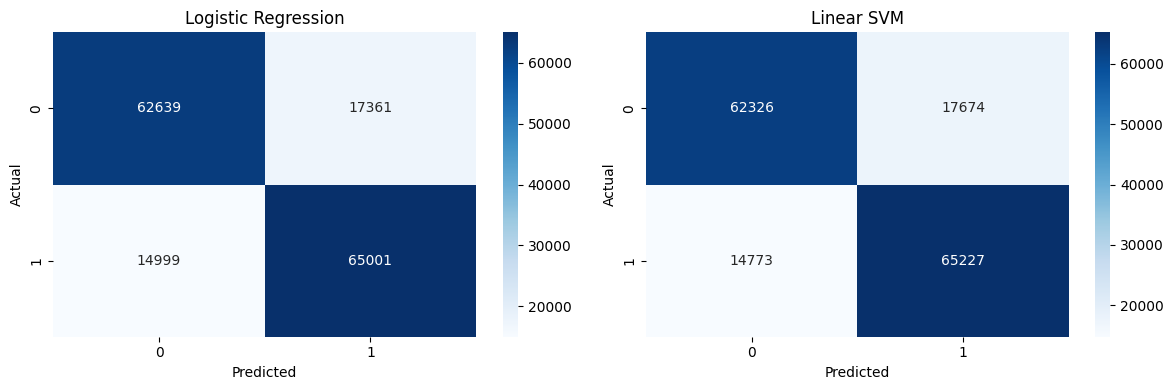

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, report in report_store.items():
    print(model_name)
    print(report)

fig, axes = plt.subplots(1, len(prediction_store), figsize=(12, 4))

if len(prediction_store) == 1:
    axes = [axes]

for ax, (model_name, predictions) in zip(axes, prediction_store.items()):
    cm = confusion_matrix(test_df['target'], predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(model_name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.tight_layout()
plt.show()


## Draft Evaluation

We evaluate the classical baselines on a fixed stratified train/validation/test split so that each model sees the same data and can be compared fairly. Hyperparameters for the SVM baseline are selected on the validation split, and the final comparison is reported only once on the held-out test set. This prevents the test set from influencing model selection.

The primary metrics are accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices. Accuracy gives an overall summary of correct predictions, while precision, recall, and F1 provide a more detailed view of class-wise behavior. ROC-AUC captures ranking quality independent of a fixed threshold, and confusion matrices make it easier to diagnose whether a model over-predicts positive or negative sentiment. To keep the comparison practical, we also record training time, inference time, and throughput in tweets per second.

To study robustness, we evaluate each model on both the full test set and a noisy subset containing tweets with Twitter-specific artifacts such as hashtags, mentions, URLs, repeated characters, emoticons, emojis, and common slang. Comparing the performance drop between the full test set and the noisy subset gives a direct measure of how sensitive each classical model is to noisy social-media text.


## Error Analysis Method and Success Criteria

Error analysis will focus on false positives and false negatives from the held-out test set. Representative errors should be grouped into common categories such as negation, sarcasm, emoji-heavy posts, slang, abbreviations, misspellings, repeated characters, and cases where sentiment depends on context that is not explicit in the tweet. This analysis should be repeated for the noisy subset to determine whether Twitter-specific noise changes the dominant failure modes.

The Member 2 contribution will be considered complete when the notebook includes a tuned linear SVM baseline, reports accuracy, precision, recall, F1, ROC-AUC, and confusion matrices on the shared split, and compares full-test versus noisy-subset performance. The written evaluation section should explain the metrics and fairness of the comparison, and the error-analysis section should clearly describe how failure cases will be inspected and interpreted.
